In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

In [4]:
df = pd.read_csv(r'../data/software_defect_prediction_dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (60000, 23)


,lines_of_code,cyclomatic_complexity,num_functions,num_classes,comment_density,code_churn,developer_experience_years,num_developers,commit_frequency,bug_fix_commits,past_defects,test_coverage,duplication_percentage,avg_function_length,depth_of_inheritance,response_for_class,coupling_between_objects,lack_of_cohesion,build_failures,static_analysis_warnings,security_vulnerabilities,performance_issues,defect
0,910,12,7,79,0.59,539,19,4,23,7,23,0.34,0.01,70,1,54,27,0.06,3,20,31,21,1
1,3822,9,197,72,0.30,584,8,8,126,153,19,0.24,0.39,180,5,73,23,0.39,9,154,38,29,1
2,3142,20,99,92,0.11,593,0,6,272,177,2,0.45,0.30,152,5,9,31,0.08,7,425,22,6,1
3,516,39,52,79,0.18,81,12,14,16,0,46,0.82,0.12,159,9,23,12,0.44,2,339,24,12,1
4,4476,27,162,75,0.21,918,14,1,164,109,29,0.46,0.20,169,2,84,9,0.41,3,111,19,2,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   lines_of_code               60000 non-null  int64  
 1   cyclomatic_complexity       60000 non-null  int64  
 2   num_functions               60000 non-null  int64  
 3   num_classes                 60000 non-null  int64  
 4   comment_density             60000 non-null  float64
 5   code_churn                  60000 non-null  int64  
 6   developer_experience_years  60000 non-null  int64  
 7   num_developers              60000 non-null  int64  
 8   commit_frequency            60000 non-null  int64  
 9   bug_fix_commits             60000 non-null  int64  
 10  past_defects                60000 non-null  int64  
 11  test_coverage               60000 non-null  float64
 12  duplication_percentage      60000 non-null  float64
 13  avg_function_length         60000 non-null

In [6]:
df['defect'].value_counts()
print("defect in number:", df.defect.value_counts())
df['defect'].value_counts(normalize=True).round(2) * 100

defect in number: defect
1    58223
0     1777
Name: count, dtype: int64


defect
1    97.0
0     3.0
Name: proportion, dtype: float64

In [7]:
df.describe().round(2)

,lines_of_code,cyclomatic_complexity,num_functions,num_classes,comment_density,code_churn,developer_experience_years,num_developers,commit_frequency,bug_fix_commits,past_defects,test_coverage,duplication_percentage,avg_function_length,depth_of_inheritance,response_for_class,coupling_between_objects,lack_of_cohesion,build_failures,static_analysis_warnings,security_vulnerabilities,performance_issues,defect
count,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00
mean,2530.35,25.09,99.90,49.37,0.30,500.25,9.47,7.49,150.30,99.26,24.52,0.55,0.20,102.11,4.51,49.99,25.10,0.50,9.47,248.72,24.45,14.47,0.97
std,1428.23,14.11,57.37,28.83,0.17,288.72,5.77,4.03,86.38,57.77,14.43,0.26,0.12,56.28,2.87,28.72,14.14,0.29,5.75,144.01,14.46,8.66,0.17
min,50.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.10,0.00,5.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1299.00,13.00,50.00,24.00,0.15,251.00,4.00,4.00,76.00,49.00,12.00,0.33,0.10,53.00,2.00,25.00,13.00,0.25,4.00,124.00,12.00,7.00,1.00
50%,2534.00,25.00,99.00,49.00,0.30,501.00,9.00,7.00,151.00,99.00,25.00,0.55,0.20,102.00,5.00,50.00,25.00,0.50,9.00,249.00,24.00,14.00,1.00
75%,3763.00,37.00,149.00,74.00,0.45,750.00,14.00,11.00,225.00,149.00,37.00,0.77,0.30,151.00,7.00,75.00,37.00,0.75,14.00,373.00,37.00,22.00,1.00
max,4999.00,49.00,199.00,99.00,0.60,999.00,19.00,14.00,299.00,199.00,49.00,1.00,0.40,199.00,9.00,99.00,49.00,1.00,19.00,499.00,49.00,29.00,1.00


C:\Users\HP\AppData\Local\Temp\ipykernel_2692\2175621497.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='defect', data=df, palette='Set2')


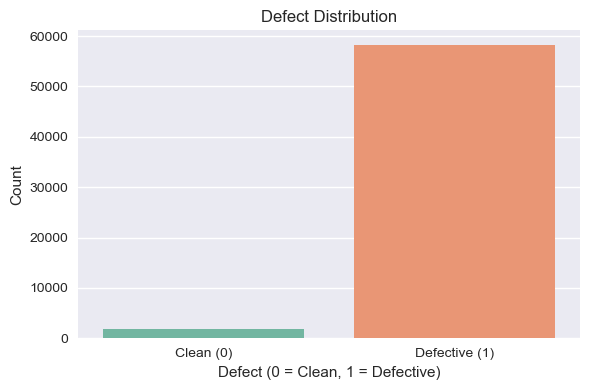

In [8]:
# Plot defect distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='defect', data=df, palette='Set2')
plt.title('Defect Distribution')
plt.xlabel('Defect (0 = Clean, 1 = Defective)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Clean (0)', 'Defective (1)'])
plt.tight_layout()
# plt.savefig('../outputs/figures/defect_distribution.png')
plt.show()

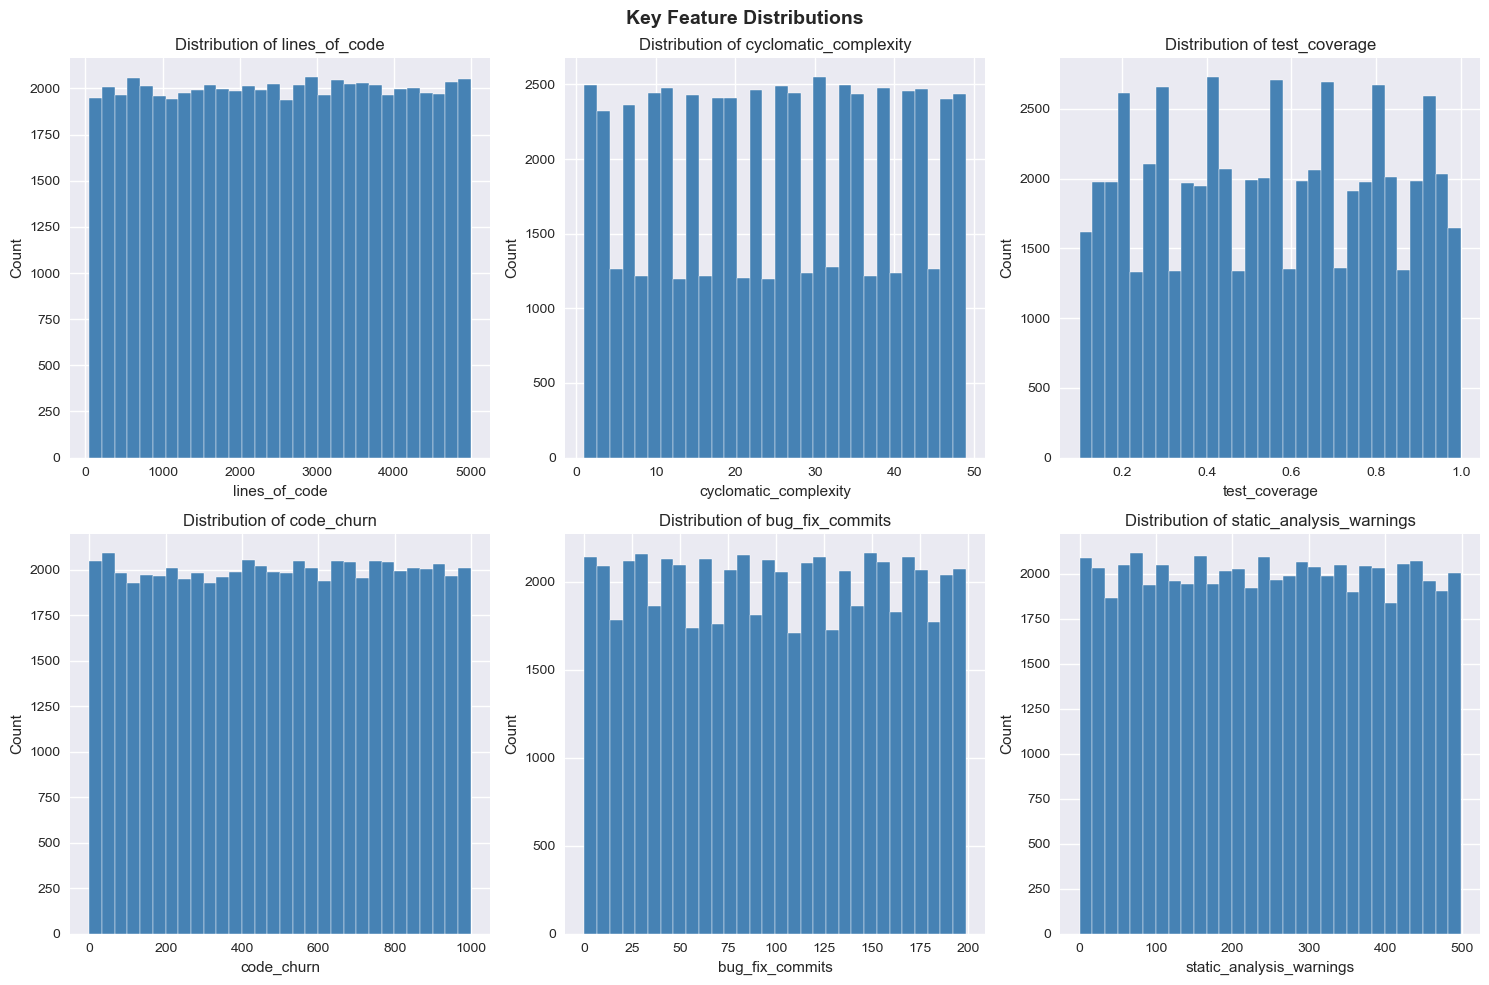

In [9]:
key_features = ['lines_of_code', 'cyclomatic_complexity', 'test_coverage', 'code_churn', 'bug_fix_commits', 'static_analysis_warnings']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes= axes.flatten()  

for i, feature in enumerate(key_features):
    axes[i].hist(df[feature], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')

plt.suptitle('Key Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/feature_distributions.png')
plt.show()

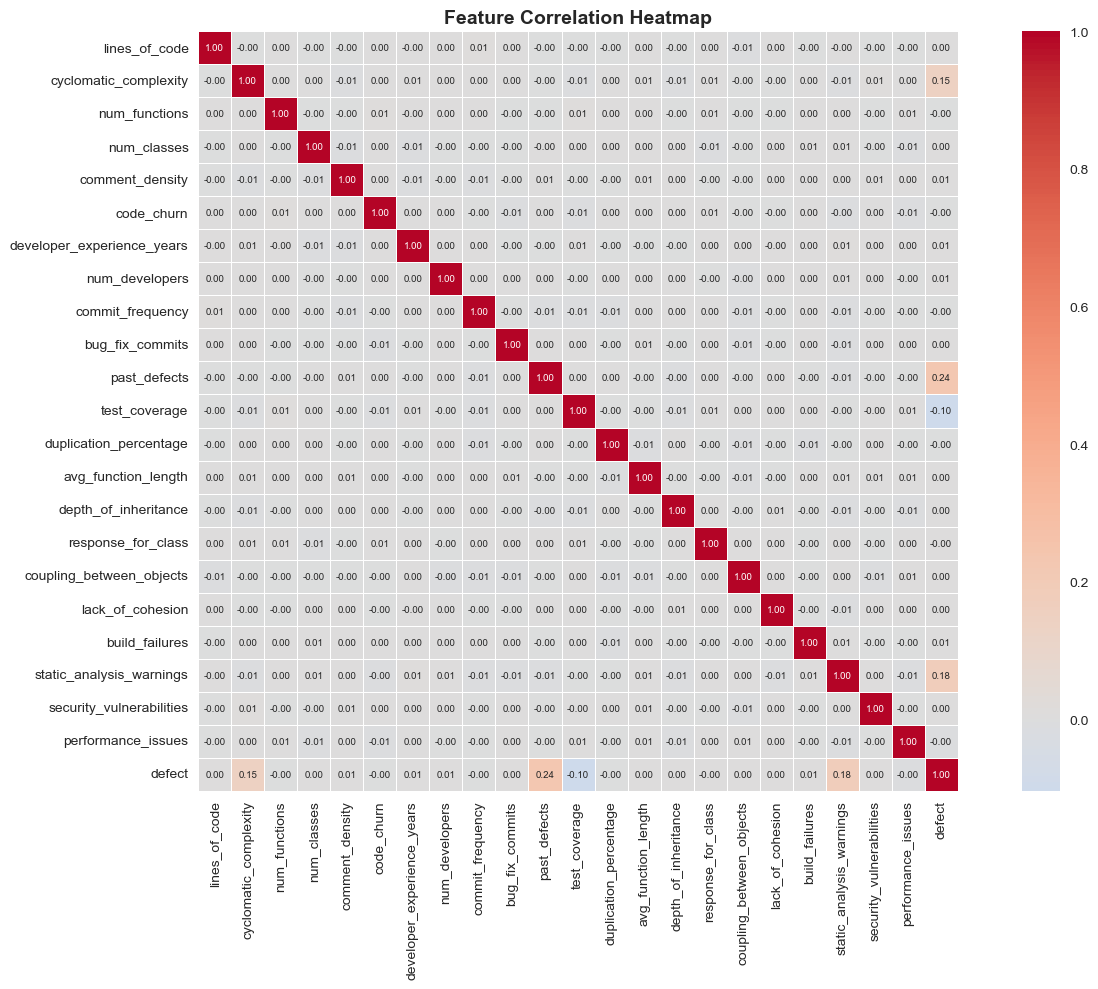

In [10]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 7}
)

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap.png')
plt.show()

In [11]:
# Separate features (X) and target (y)
X = df.drop('defect', axis=1)
y = df['defect']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", list(X.columns))

Features shape: (60000, 22)
Target shape: (60000,)

Feature columns: ['lines_of_code', 'cyclomatic_complexity', 'num_functions', 'num_classes', 'comment_density', 'code_churn', 'developer_experience_years', 'num_developers', 'commit_frequency', 'bug_fix_commits', 'past_defects', 'test_coverage', 'duplication_percentage', 'avg_function_length', 'depth_of_inheritance', 'response_for_class', 'coupling_between_objects', 'lack_of_cohesion', 'build_failures', 'static_analysis_warnings', 'security_vulnerabilities', 'performance_issues']


In [ ]:
# Spliting data: 80% training, 20% testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())
print("\nTesting target distribution:")
print(y_test.value_counts())

Training set size: (48000, 22)
Testing set size: (12000, 22)

Training target distribution:
defect
1    46578
0     1422
Name: count, dtype: int64

Testing target distribution:
defect
1    11645
0      355
Name: count, dtype: int64


In [15]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set mean (first 5 features):", 
      X_train_scaled[:, :5].mean(axis=0).round(4))
print("Training set std (first 5 features):", 
      X_train_scaled[:, :5].std(axis=0).round(4))

Training set mean (first 5 features): [ 0. -0.  0. -0.  0.]
Training set std (first 5 features): [1. 1. 1. 1. 1.]


In [16]:
from sklearn.linear_model import LogisticRegression
import time

# Initialize the model
lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

# Train the model
print("Training Logistic Regression...")
start = time.time()
lr_model.fit(X_train_scaled, y_train)
end = time.time()

print(f"Training complete in {round(end - start, 2)} seconds")
print("Model trained successfully.")

Training Logistic Regression...
Training complete in 0.13 seconds
Model trained successfully.


Accuracy: 93.29%

Classification Report:
               precision    recall  f1-score   support

    Clean (0)       0.30      0.98      0.46       355
Defective (1)       1.00      0.93      0.96     11645

     accuracy                           0.93     12000
    macro avg       0.65      0.96      0.71     12000
 weighted avg       0.98      0.93      0.95     12000



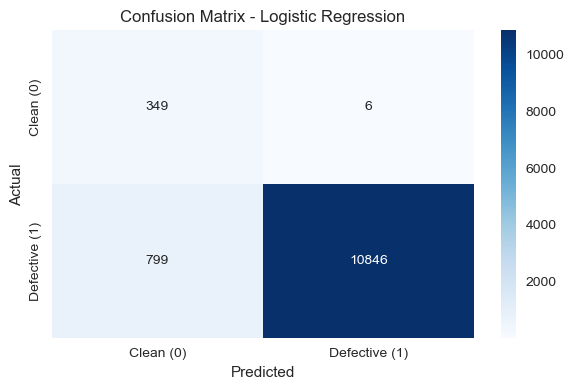

In [17]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {round(accuracy * 100, 2)}%")

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, 
      target_names=['Clean (0)', 'Defective (1)']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Clean (0)', 'Defective (1)'],
            yticklabels=['Clean (0)', 'Defective (1)'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix_lr.png')
plt.show()

Training Decision Tree...
Training complete in 0.09 seconds

Accuracy: 100.0%

Classification Report:
               precision    recall  f1-score   support

    Clean (0)       1.00      1.00      1.00       355
Defective (1)       1.00      1.00      1.00     11645

     accuracy                           1.00     12000
    macro avg       1.00      1.00      1.00     12000
 weighted avg       1.00      1.00      1.00     12000



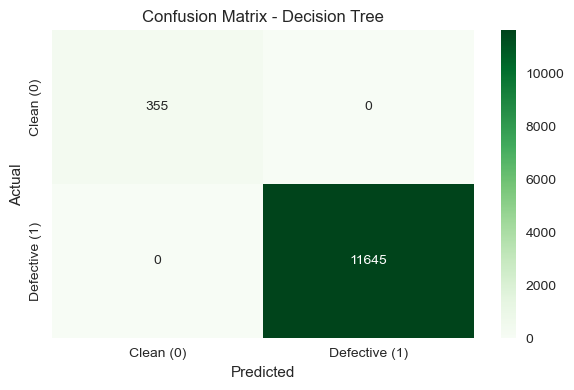

In [18]:
from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree
dt_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42,
    max_depth=10
)

# Train
print("Training Decision Tree...")
start = time.time()
dt_model.fit(X_train_scaled, y_train)
end = time.time()
print(f"Training complete in {round(end - start, 2)} seconds")

# Predictions
y_pred_dt = dt_model.predict(X_test_scaled)

# Accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"\nAccuracy: {round(accuracy_dt * 100, 2)}%")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt,
      target_names=['Clean (0)', 'Defective (1)']))

# Confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Clean (0)', 'Defective (1)'],
            yticklabels=['Clean (0)', 'Defective (1)'])
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix_dt.png')
plt.show()

Training Decision Tree v2...
Training complete in 0.09 seconds

Accuracy: 100.0%

Classification Report:
               precision    recall  f1-score   support

    Clean (0)       1.00      1.00      1.00       355
Defective (1)       1.00      1.00      1.00     11645

     accuracy                           1.00     12000
    macro avg       1.00      1.00      1.00     12000
 weighted avg       1.00      1.00      1.00     12000



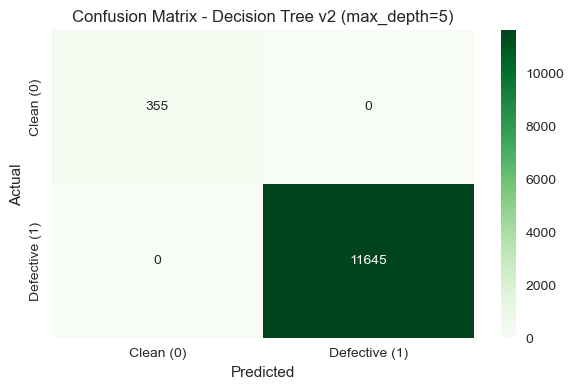

In [19]:
# Retrain with lower max_depth to reduce overfitting
dt_model_v2 = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42,
    max_depth=5  # Reduced from 10 to 5
)

# Train
print("Training Decision Tree v2...")
start = time.time()
dt_model_v2.fit(X_train_scaled, y_train)
end = time.time()
print(f"Training complete in {round(end - start, 2)} seconds")

# Predictions
y_pred_dt_v2 = dt_model_v2.predict(X_test_scaled)

# Accuracy
accuracy_dt_v2 = accuracy_score(y_test, y_pred_dt_v2)
print(f"\nAccuracy: {round(accuracy_dt_v2 * 100, 2)}%")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt_v2,
      target_names=['Clean (0)', 'Defective (1)']))

# Confusion matrix
cm_dt_v2 = confusion_matrix(y_test, y_pred_dt_v2)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt_v2, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Clean (0)', 'Defective (1)'],
            yticklabels=['Clean (0)', 'Defective (1)'])
plt.title('Confusion Matrix - Decision Tree v2 (max_depth=5)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix_dt_v2.png')
plt.show()

In [20]:
# Quick test with max_depth=3
dt_model_v3 = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42,
    max_depth=3
)

dt_model_v3.fit(X_train_scaled, y_train)
y_pred_dt_v3 = dt_model_v3.predict(X_test_scaled)
accuracy_dt_v3 = accuracy_score(y_test, y_pred_dt_v3)
print(f"Accuracy with max_depth=3: {round(accuracy_dt_v3 * 100, 2)}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt_v3,
      target_names=['Clean (0)', 'Defective (1)']))

Accuracy with max_depth=3: 98.67%

Classification Report:
               precision    recall  f1-score   support

    Clean (0)       0.69      1.00      0.82       355
Defective (1)       1.00      0.99      0.99     11645

     accuracy                           0.99     12000
    macro avg       0.85      0.99      0.91     12000
 weighted avg       0.99      0.99      0.99     12000



Model Comparison:
                   Model  Accuracy  Clean Recall  Defect Recall  Clean F1  Defect F1 Overfit Risk
     Logistic Regression     93.29          0.98           0.93      0.46       0.96          Low
Decision Tree (depth=10)    100.00          1.00           1.00      1.00       1.00         High
 Decision Tree (depth=5)    100.00          1.00           1.00      1.00       1.00         High
 Decision Tree (depth=3)     98.67          1.00           0.99      0.82       0.99       Medium


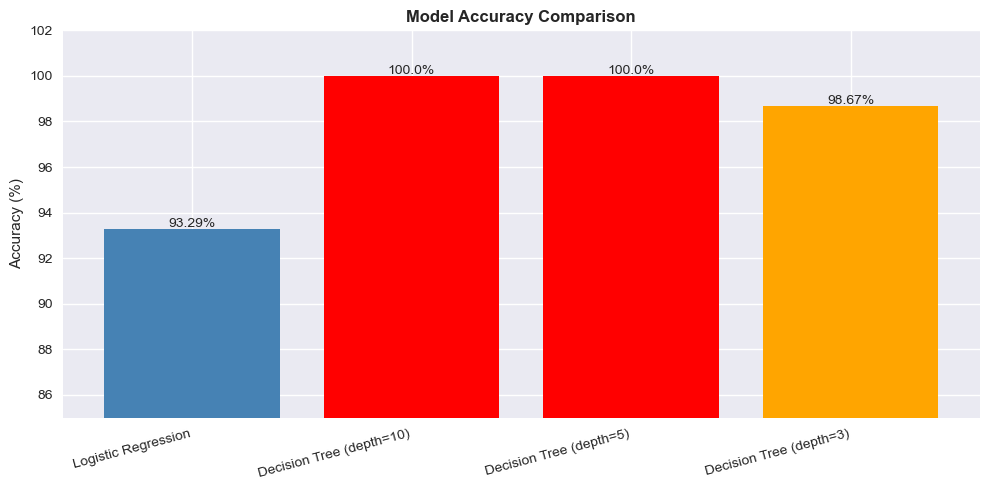

In [21]:
# Model comparison summary
results = {
    'Model': [
        'Logistic Regression',
        'Decision Tree (depth=10)',
        'Decision Tree (depth=5)',
        'Decision Tree (depth=3)'
    ],
    'Accuracy': [93.29, 100.00, 100.00, 98.67],
    'Clean Recall': [0.98, 1.00, 1.00, 1.00],
    'Defect Recall': [0.93, 1.00, 1.00, 0.99],
    'Clean F1': [0.46, 1.00, 1.00, 0.82],
    'Defect F1': [0.96, 1.00, 1.00, 0.99],
    'Overfit Risk': ['Low', 'High', 'High', 'Medium']
}

results_df = pd.DataFrame(results)
print("Model Comparison:")
print(results_df.to_string(index=False))

# Plot accuracy comparison
plt.figure(figsize=(10, 5))
colors = ['steelblue', 'red', 'red', 'orange']
bars = plt.bar(results['Model'], results['Accuracy'], color=colors)
plt.title('Model Accuracy Comparison', fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(85, 102)
plt.xticks(rotation=15, ha='right')

# Add value labels on bars
for bar, val in zip(bars, results['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{val}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/figures/model_comparison.png')
plt.show()

Top 10 Most Important Features:
                   Feature   Importance
              past_defects 6.911659e-01
  static_analysis_warnings 2.216886e-01
     cyclomatic_complexity 8.714552e-02
      depth_of_inheritance 3.105357e-12
             num_functions 0.000000e+00
             lines_of_code 0.000000e+00
                code_churn 0.000000e+00
           comment_density 0.000000e+00
               num_classes 0.000000e+00
developer_experience_years 0.000000e+00


C:\Users\HP\AppData\Local\Temp\ipykernel_2692\1584922818.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


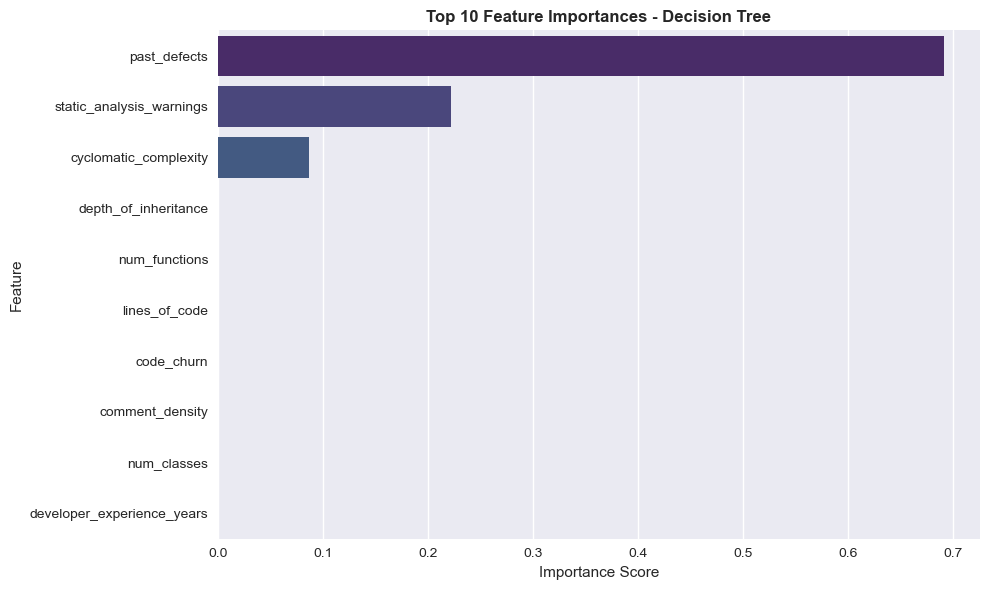

In [22]:
# Get feature importance from Decision Tree depth=3
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model_v3.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features,
    palette='viridis'
)
plt.title('Top 10 Feature Importances - Decision Tree', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance.png')
plt.show()

In [23]:
import pickle
import os

# Save the logistic regression model
model_path = '../outputs/models/logistic_regression_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(lr_model, f)

# Save the scaler too, always needed alongside the model
scaler_path = '../outputs/models/scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved to:", model_path)
print("Scaler saved to:", scaler_path)
print("\nSaved files:")
for f in os.listdir('../outputs/models/'):
    print(f" - {f}")

Model saved to: ../outputs/models/logistic_regression_model.pkl
Scaler saved to: ../outputs/models/scaler.pkl

Saved files:
 - logistic_regression_model.pkl
 - scaler.pkl


In [24]:
# Final project summary
print("=" * 60)
print("PROJECT 1: BUG/DEFECT PREDICTOR - SUMMARY")
print("=" * 60)

print("\nDATASET:")
print(f"  Total samples       : {df.shape[0]:,}")
print(f"  Total features      : {df.shape[1] - 1}")
print(f"  Defective modules   : {(y == 1).sum():,} (97%)")
print(f"  Clean modules       : {(y == 0).sum():,} (3%)")

print("\nMODEL PERFORMANCE:")
print(f"  Logistic Regression : {93.29}% accuracy (Low overfit risk)")
print(f"  Decision Tree d=10  : {100.00}% accuracy (High overfit risk)")
print(f"  Decision Tree d=5   : {100.00}% accuracy (High overfit risk)")
print(f"  Decision Tree d=3   : {98.67}% accuracy (Medium overfit risk)")

print("\nBEST MODEL: Logistic Regression")
print("  Reason: Most trustworthy, lowest overfit risk")
print("  Defect Recall: 93% (catches 93% of real bugs)")

print("\nTOP PREDICTIVE FEATURES:")
print("  1. past_defects            (69% importance)")
print("  2. static_analysis_warnings (22% importance)")
print("  3. cyclomatic_complexity    (9% importance)")

print("\nKEY LESSONS LEARNED:")
print("  1. High accuracy does not always mean good model")
print("  2. Class imbalance must be handled before training")
print("  3. Feature importance reveals what truly matters")
print("  4. Always question results that seem too perfect")
print("  5. Synthetic data produces unrealistic benchmarks")

print("\nSAVED OUTPUTS:")
print("  - outputs/figures/defect_distribution.png")
print("  - outputs/figures/feature_distributions.png")
print("  - outputs/figures/correlation_heatmap.png")
print("  - outputs/figures/confusion_matrix_lr.png")
print("  - outputs/figures/confusion_matrix_dt.png")
print("  - outputs/figures/confusion_matrix_dt_v2.png")
print("  - outputs/figures/model_comparison.png")
print("  - outputs/figures/feature_importance.png")
print("  - outputs/models/logistic_regression_model.pkl")
print("  - outputs/models/scaler.pkl")

print("\n" + "=" * 60)
print("PROJECT STATUS: COMPLETE")
print("=" * 60)

PROJECT 1: BUG/DEFECT PREDICTOR - SUMMARY

DATASET:
  Total samples       : 60,000
  Total features      : 22
  Defective modules   : 58,223 (97%)
  Clean modules       : 1,777 (3%)

MODEL PERFORMANCE:
  Logistic Regression : 93.29% accuracy (Low overfit risk)
  Decision Tree d=10  : 100.0% accuracy (High overfit risk)
  Decision Tree d=5   : 100.0% accuracy (High overfit risk)
  Decision Tree d=3   : 98.67% accuracy (Medium overfit risk)

BEST MODEL: Logistic Regression
  Reason: Most trustworthy, lowest overfit risk
  Defect Recall: 93% (catches 93% of real bugs)

TOP PREDICTIVE FEATURES:
  1. past_defects            (69% importance)
  2. static_analysis_warnings (22% importance)
  3. cyclomatic_complexity    (9% importance)

KEY LESSONS LEARNED:
  1. High accuracy does not always mean good model
  2. Class imbalance must be handled before training
  3. Feature importance reveals what truly matters
  4. Always question results that seem too perfect
  5. Synthetic data produces unreal